# Inspection of variables after Full Selection

**_run with dfs created with the full selection_**

This notebook inspects the selected events after the full event selection 

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")

In [34]:
save_fig = True

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "selected_events-DATA-1e20/Dev")
save_fig_dir_perTPC = path.join(save_fig_base_dir, "selected_events-DATA-1e20-perTPC/Dev")
save_fig_dir_TPC1 = path.join(save_fig_base_dir, "selected_events-DATA-1e20-TPC1/Dev")
save_fig_dir_TPC2 = path.join(save_fig_base_dir, "selected_events-DATA-1e20-TPC2/Dev")
save_fig_dir_octant = path.join(save_fig_dir, "by_octant")

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

    if not path.exists(save_fig_dir_perTPC):
        makedirs(save_fig_dir_perTPC)
    print("saving plots in ", save_fig_dir_perTPC)

    if not path.exists(save_fig_dir_TPC1):
        makedirs(save_fig_dir_TPC1)
    print("saving plots in ", save_fig_dir_TPC1)

    if not path.exists(save_fig_dir_TPC2):
        makedirs(save_fig_dir_TPC2)
    print("saving plots in ", save_fig_dir_TPC2)

    if not path.exists(save_fig_dir_octant):
        makedirs(save_fig_dir_octant)
    print("saving plots in ", save_fig_dir_octant)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-DATA-1e20/Dev
saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-DATA-1e20-perTPC/Dev
saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-DATA-1e20-TPC1/Dev
saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-DATA-1e20-TPC2/Dev
saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-DATA-1e20/Dev/by_octant


# Load dfs

In [ ]:
dfs = get_ana_dfs(option="selected_events")

mc_evt_df     = dfs["mc"]
mc_hdr_df     = dfs["mc_hdr"]
data_evt_df_   = dfs["data"]
data_hdr_df_   = dfs["data_hdr"]
intime_evt_df = dfs["intime"]
intime_hdr_df = dfs["intime_hdr"]
dirt_evt_df   = dfs["dirt"]
dirt_hdr_df   = dfs["dirt_hdr"]

pot_label     = dfs["pot_label"]

In [ ]:
# from pyanalib.split_df_helpers_new import *

# df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_164044__sel_2prong-data-BNB_cosmics"
# keys2load_data = ['hdr', 'evt']
# df_data = dfs_from_dir(search_dir=df_dir, filename_str="sel_2prong-data-BNB_cosmics", keys2load=keys2load_data, n_max_concat=999)

# data_evt_df = df_data['evt']
# data_hdr_df = df_data['hdr']

# df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_042101__sel_2prong-mc-BNB_cosmics"
# keys2load_data = ['hdr', 'evt']
# df_data = dfs_from_dir(search_dir=df_dir, filename_str="sel_2prong-mc-BNB_cosmics", keys2load=keys2load_data, n_max_concat=999)
# mc_evt_df = df_data['evt']
# mc_hdr_df = df_data['hdr']

In [ ]:
data_evt_df = data_evt_df_
data_hdr_df = data_hdr_df_

In [ ]:
mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc","iscc")] = 999
data_evt_df_["mc", "iscc"] = 999

In [ ]:
import pickle

def get_syst_unc(var_config):
    date_str = "20260220"
    mcstat_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/mcstat_syst_dict.npz", allow_pickle=True)
    mcstat_syst =dict(mcstat_syst)[var_config.var_save_name].item()['MCstat']['cov_frac']

    g4_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/g4_syst_dict.npz", allow_pickle=True)
    g4_syst =dict(g4_syst)[var_config.var_save_name].item()['G4']['cov_frac']

    flux_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/flux_syst_dict.npz", allow_pickle=True)
    flux_syst =dict(flux_syst)[var_config.var_save_name].item()['flux']['cov_frac']

    date_str = "20260222"
    cosmics_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/cosmics_syst_dict.npz", allow_pickle=True)
    cosmics_syst =dict(cosmics_syst)[var_config.var_save_name].item()['Cosmics']['cov_frac']

    date_str = "20260219"
    genie_syst = pickle.load(open(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/cov_mat_dict-{date_str}.pkl", "rb"))
    genie_syst = genie_syst[var_config.var_save_name]['genie'] 

    # detvar_syst = pickle.load(open("/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts/det_unc_dict-20260216.pkl", "rb"))
    # detvar_syst = detvar_syst[var_config.var_save_name]['detvar']

    # detvar_syst = pickle.load(open("/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts/det_unc_dict-20260216.pkl", "rb"))
    # detvar_syst = np.sqrt(detvar_syst[var_config.var_save_name]['ccal']**2 \
    #     + detvar_syst[var_config.var_save_name]['alpha']**2 \
    #     + detvar_syst[var_config.var_save_name]['beta']**2 \
    #     + detvar_syst[var_config.var_save_name]['R']**2) / 2.


    # flat uncertainties
    pot_frac_unc = 0.02
    ntargets_frac_unc = 0.01

    # flat uncertainties
    frac_uncert_total = np.zeros(len(var_config.bin_centers))
    cov_total = np.zeros((len(var_config.bin_centers), len(var_config.bin_centers)))
    systs      = [mcstat_syst, genie_syst, flux_syst, g4_syst, cosmics_syst]
    for syst in systs:
        cov_total += syst
        syst_uncert = np.sqrt(np.diag(syst))
        frac_uncert_total += syst_uncert ** 2

    flat_systs = [pot_frac_unc, ntargets_frac_unc]
    for syst in flat_systs:
        cov_total += np.diag(syst * np.ones(len(var_config.bin_centers)) ** 2)
        syst_uncert = syst * np.ones(len(var_config.bin_centers))
        frac_uncert_total += syst_uncert ** 2

    # frac_uncert_total += detvar_syst ** 2

    frac_uncert_total = np.sqrt(frac_uncert_total)
    # syst = frac_uncert_total

    return cov_total, frac_uncert_total

In [ ]:
# mc_evt_df[(mc_evt_df.mu.pfp.trk.len > 328) & (mc_evt_df.mu.pfp.trk.len < 329)].mu.pfp.trk.truth.p.totp
# mc_evt_df[(mc_evt_df.p.pfp.trk.len > 8.5) & (mc_evt_df.p.pfp.trk.len < 8.7)].p.pfp.trk.truth.p.totp

# Distribution of Selected Events

In [ ]:
var_config = VariableConfig.list_all_configs(print_summary=False)

In [ ]:
mc_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], mc_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
mc_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], mc_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

data_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(data_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], data_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
data_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(data_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], data_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

intime_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(intime_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], intime_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
intime_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(intime_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], intime_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

# dirt_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(dirt_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], dirt_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
# dirt_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(dirt_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], dirt_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

# ==== Inspect Corrleation between phi and the measurement variables

In [ ]:
# VariableConfig.muon_direction_phi()

measurement_var_configs = [
    VariableConfig.all_events(),
    VariableConfig.muon_momentum(),
    VariableConfig.muon_direction(),
    VariableConfig.proton_momentum(),
    VariableConfig.proton_direction(),
    VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_Tp_x(),
    VariableConfig.tki_del_Tp_y(),
    VariableConfig.tki_del_p(),
    VariableConfig.tki_del_alpha(),
    VariableConfig.tki_del_phi(),
    ]

In [ ]:

# ===== 2D Correlation: phi_mu vs each measurement variable =====
#
# For each measurement variable we produce two figures:
#
# Figure 1 — 2D histograms (phi_mu on x, measurement var on y):
#   left  : Data counts
#   center: MC (POT-scaled)
#   right : Data/MC ratio
#   → If the anomaly is *purely a phi effect*, the ratio panel shows a
#     vertical stripe (uniform in the measurement-var direction).
#   → If the deficit is also localized in the measurement variable, the
#     ratio panel will show a blob concentrated in a sub-region.
#
# Figure 2 — 1D measurement-variable distributions in two phi slices:
#   left  : events in the anomalous phi window  [-100°, -50°]
#   right : events outside that window
#   → Comparing data vs MC in each slice shows whether the anomaly
#     produces a flat scale change (spread) or a shape distortion (localized).

from matplotlib.colors import Normalize

phi_var_col  = ('mu', 'pfp', 'trk', 'phi', '', '', '')
phi_bins     = np.linspace(-180, 180, 21)   # 18 deg / bin — same as VariableConfig
phi_anom_lo  = -100.                        # anomalous window (consistent with analysis below)
phi_anom_hi  = -50.

pot_weight_mc     = mc_evt_df.pot_weight.unique()[0]
pot_weight_intime = intime_evt_df.pot_weight.unique()[0]

for var_config in measurement_var_configs:
    if var_config.var_save_name == "integrated":
        continue

    var_col   = var_config.var_evt_reco_col
    var_bins  = var_config.bins
    var_label = var_config.var_labels[1]

    # ---- raw arrays (aligned to their respective DataFrames) ----
    phi_d  = data_evt_df[phi_var_col].values
    phi_m  = mc_evt_df[phi_var_col].values
    phi_it = intime_evt_df[phi_var_col].values

    var_d  = data_evt_df[var_col].values
    var_m  = mc_evt_df[var_col].values
    var_it = intime_evt_df[var_col].values

    # finite-value masks
    mk_d  = np.isfinite(phi_d)  & np.isfinite(var_d)
    mk_m  = np.isfinite(phi_m)  & np.isfinite(var_m)
    mk_it = np.isfinite(phi_it) & np.isfinite(var_it)

    # ================================================================
    # Figure 1 — 2D histograms
    # ================================================================
    h_d,  xe, ye = np.histogram2d(phi_d[mk_d],   var_d[mk_d],   bins=[phi_bins, var_bins])
    h_m,   _,  _ = np.histogram2d(phi_m[mk_m],   var_m[mk_m],   bins=[phi_bins, var_bins],
                                   weights=np.full(mk_m.sum(),  pot_weight_mc))
    h_it,  _,  _ = np.histogram2d(phi_it[mk_it], var_it[mk_it], bins=[phi_bins, var_bins],
                                   weights=np.full(mk_it.sum(), pot_weight_intime))
    h_mc      = h_m + h_it
    ratio_2d  = np.where(h_mc > 0, h_d / h_mc, np.nan)

    Xm, Ym = np.meshgrid(xe, ye)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(rf"2D: $\phi_\mu$ vs {var_label}", fontsize=13)

    im0 = axes[0].pcolormesh(Xm, Ym, h_d.T,  cmap="Blues")
    fig.colorbar(im0, ax=axes[0], label="Events")
    axes[0].set_title("Data")

    im1 = axes[1].pcolormesh(Xm, Ym, h_mc.T, cmap="Oranges")
    fig.colorbar(im1, ax=axes[1], label="Events (POT-scaled)")
    axes[1].set_title("MC (POT-scaled)")

    im2 = axes[2].pcolormesh(Xm, Ym, ratio_2d.T, cmap="RdBu_r",
                              norm=Normalize(vmin=0.5, vmax=1.5))
    fig.colorbar(im2, ax=axes[2], label="Data / MC")
    axes[2].set_title("Data / MC")
    axes[2].axvline(phi_anom_lo, color="k", ls="--", lw=1.5, label="anomaly window")
    axes[2].axvline(phi_anom_hi, color="k", ls="--", lw=1.5)
    axes[2].legend(fontsize=9)

    for ax in axes:
        ax.set_xlabel(r"$\phi_\mu^{\rm reco.}$ (deg)", fontsize=11)
        ax.set_ylabel(var_label, fontsize=11)
        ax.axvspan(phi_anom_lo, phi_anom_hi, alpha=0.12, color="red")

    plt.tight_layout()
    plt.show()

    # ================================================================
    # Figure 2 — 1D distributions of measurement var in each phi slice
    # ================================================================
    in_anom_d  = mk_d  & (phi_d  >= phi_anom_lo) & (phi_d  <= phi_anom_hi)
    in_anom_m  = mk_m  & (phi_m  >= phi_anom_lo) & (phi_m  <= phi_anom_hi)
    in_anom_it = mk_it & (phi_it >= phi_anom_lo) & (phi_it <= phi_anom_hi)

    out_anom_d  = mk_d  & ~((phi_d  >= phi_anom_lo) & (phi_d  <= phi_anom_hi))
    out_anom_m  = mk_m  & ~((phi_m  >= phi_anom_lo) & (phi_m  <= phi_anom_hi))
    out_anom_it = mk_it & ~((phi_it >= phi_anom_lo) & (phi_it <= phi_anom_hi))

    slices = [
        (in_anom_d,  in_anom_m,  in_anom_it,
         rf"$\phi_\mu \in [{phi_anom_lo:.0f}°,\ {phi_anom_hi:.0f}°]$  (anomaly window)"),
        (out_anom_d, out_anom_m, out_anom_it,
         rf"$\phi_\mu \notin [{phi_anom_lo:.0f}°,\ {phi_anom_hi:.0f}°]$  (rest of events)"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9),
                              gridspec_kw={"height_ratios": [3, 1]})
    fig.suptitle(rf"{var_label} — Data vs MC in $\phi_\mu$ slices", fontsize=13)

    bin_centers = (var_bins[:-1] + var_bins[1:]) / 2.
    eps_ratio   = 1e-8

    for col_idx, (mask_d_sl, mask_m_sl, mask_it_sl, slice_label) in enumerate(slices):
        ax_top = axes[0, col_idx]
        ax_bot = axes[1, col_idx]

        h_d_sl,  _ = np.histogram(var_d[mask_d_sl],   bins=var_bins)
        h_m_sl,  _ = np.histogram(var_m[mask_m_sl],   bins=var_bins,
                                    weights=np.full(mask_m_sl.sum(),  pot_weight_mc))
        h_it_sl, _ = np.histogram(var_it[mask_it_sl], bins=var_bins,
                                    weights=np.full(mask_it_sl.sum(), pot_weight_intime))
        h_mc_sl    = h_m_sl + h_it_sl

        ax_top.step(var_bins[:-1], h_d_sl,  where="post", color="black",     label="Data",          lw=1.5)
        ax_top.step(var_bins[:-1], h_mc_sl, where="post", color="steelblue", label="MC (POT-scaled)", lw=1.5)
        ax_top.set_ylabel("Events", fontsize=11)
        ax_top.set_title(slice_label, fontsize=10)
        ax_top.legend(fontsize=9)
        ax_top.set_xlim(var_bins[0], var_bins[-1])

        ratio_1d = np.where(h_mc_sl > 0, h_d_sl / (h_mc_sl + eps_ratio), np.nan)
        ax_bot.step(var_bins[:-1], ratio_1d, where="post", color="black", lw=1.5)
        ax_bot.axhline(1.0, color="steelblue", ls="--", lw=1.0)
        ax_bot.set_ylim(0, 2.5)
        ax_bot.set_ylabel("Data / MC", fontsize=10)
        ax_bot.set_xlabel(var_label, fontsize=11)
        ax_bot.set_xlim(var_bins[0], var_bins[-1])

    plt.tight_layout()
    plt.show()


In [ ]:

# ===== Column-normalized MC heatmap (per-phi-bin) =====
# Each phi-bin column integrates to 1, so you can compare *shapes* vs phi.

phi_var_col  = ('mu', 'pfp', 'trk', 'phi', '', '', '')
phi_bins     = np.linspace(-180, 180, 21)
phi_anom_lo  = -100.
phi_anom_hi  = -50.

pot_weight_mc     = mc_evt_df.pot_weight.unique()[0]
pot_weight_intime = intime_evt_df.pot_weight.unique()[0]

def col_normalize(h2d, eps=1e-12):
    # h2d shape (n_phi_bins-1, n_var_bins-1) with x=phi, y=var
    colsum = np.sum(h2d, axis=1, keepdims=True)  # sum over var-bins for each phi-bin
    return h2d / (colsum + eps)

for var_config in measurement_var_configs:
    if var_config.var_save_name == "integrated":
        continue

    var_col   = var_config.var_evt_reco_col
    var_bins  = var_config.bins
    var_label = var_config.var_labels[1]

    phi_m  = mc_evt_df[phi_var_col].values
    phi_it = intime_evt_df[phi_var_col].values

    var_m  = mc_evt_df[var_col].values
    var_it = intime_evt_df[var_col].values

    mk_m  = np.isfinite(phi_m)  & np.isfinite(var_m)
    mk_it = np.isfinite(phi_it) & np.isfinite(var_it)

    h_m, xe, ye = np.histogram2d(
        phi_m[mk_m], var_m[mk_m],
        bins=[phi_bins, var_bins],
        weights=np.full(mk_m.sum(), pot_weight_mc),
    )
    h_it, _, _ = np.histogram2d(
        phi_it[mk_it], var_it[mk_it],
        bins=[phi_bins, var_bins],
        weights=np.full(mk_it.sum(), pot_weight_intime),
    )

    h_mc_cn = col_normalize(h_m + h_it)
    Xm, Ym = np.meshgrid(xe, ye)

    fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
    # fig.suptitle(rf"MC column-normalized: $\phi_\mu$ vs {var_label}", fontsize=12)

    im = ax.pcolormesh(Xm, Ym, h_mc_cn.T, cmap="viridis", vmin=0)
    fig.colorbar(im, ax=ax) #, label="P(var | phi) (MC)")

    ax.set_xlabel(r"$\phi_\mu^{\rm reco.}$ (deg)", fontsize=11)
    ax.set_ylabel(var_label, fontsize=11)
    ax.axvspan(phi_anom_lo, phi_anom_hi, alpha=0.12, color="red")
    ax.axvline(phi_anom_lo, color="k", ls="--", lw=1.0)
    ax.axvline(phi_anom_hi, color="k", ls="--", lw=1.0)

    plt.tight_layout()
    plt.show()


# ==== End

In [22]:
perTPC_inset = 5
def perTPC_cut(df):
    in_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    in_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    perTPC_cut = in_TPC1_cut | in_TPC2_cut
    return perTPC_cut

mc_evt_df_perTPC = mc_evt_df[perTPC_cut(mc_evt_df)]
data_evt_df_perTPC = data_evt_df[perTPC_cut(data_evt_df)]
intime_evt_df_perTPC = intime_evt_df[perTPC_cut(intime_evt_df)]

def contTPC1_cut(df):
    cont_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    return cont_TPC1_cut

mc_evt_df_contTPC1 = mc_evt_df[contTPC1_cut(mc_evt_df)]
data_evt_df_contTPC1 = data_evt_df[contTPC1_cut(data_evt_df)]
intime_evt_df_contTPC1 = intime_evt_df[contTPC1_cut(intime_evt_df)]

def contTPC2_cut(df):
    cont_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    return cont_TPC2_cut

mc_evt_df_contTPC2 = mc_evt_df[contTPC2_cut(mc_evt_df)]
data_evt_df_contTPC2 = data_evt_df[contTPC2_cut(data_evt_df)]
intime_evt_df_contTPC2 = intime_evt_df[contTPC2_cut(intime_evt_df)]

def vtxinTPC1_cut(df):
    in_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=0) # & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=2.5) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=2.5)
    return in_TPC1_cut

mc_evt_df_TPC1 = mc_evt_df[vtxinTPC1_cut(mc_evt_df)]
data_evt_df_TPC1 = data_evt_df[vtxinTPC1_cut(data_evt_df)]
intime_evt_df_TPC1 = intime_evt_df[vtxinTPC1_cut(intime_evt_df)]


def vtxinTPC2_cut(df):
    in_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=0) #& InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=2.5) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=2.5)
    return in_TPC2_cut

mc_evt_df_TPC2 = mc_evt_df[vtxinTPC2_cut(mc_evt_df)]
data_evt_df_TPC2 = data_evt_df[vtxinTPC2_cut(data_evt_df)]
intime_evt_df_TPC2 = intime_evt_df[vtxinTPC2_cut(intime_evt_df)]

## Inspect distributions: SBND volume octants

Octants split the fiducial volume by reco vertex **x** (E/W), **z** (N/S), and **y** (Top/Bottom). **SBND:** negative **x** → East (`x < x0` → E); lower **z** → North (`z < z0` → N). Split points `(x0, y0, z0)` are chosen consistently across samples.

The bar plots below are only **weighted event counts** per octant axis. **Variable distributions** (Data vs stacked MC + `overlay_hists`, same as “Nominal”) are produced later in the topology `VariableConfig` loop cell and the phi loop cell, saved under `save_fig_dir_octant` / `by_octant/<octant>/`.


/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k": series, "w": weights}).groupby("k")["w"].sum()
/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k": series, "w": weights}).groupby("k")["w"].sum()
/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k

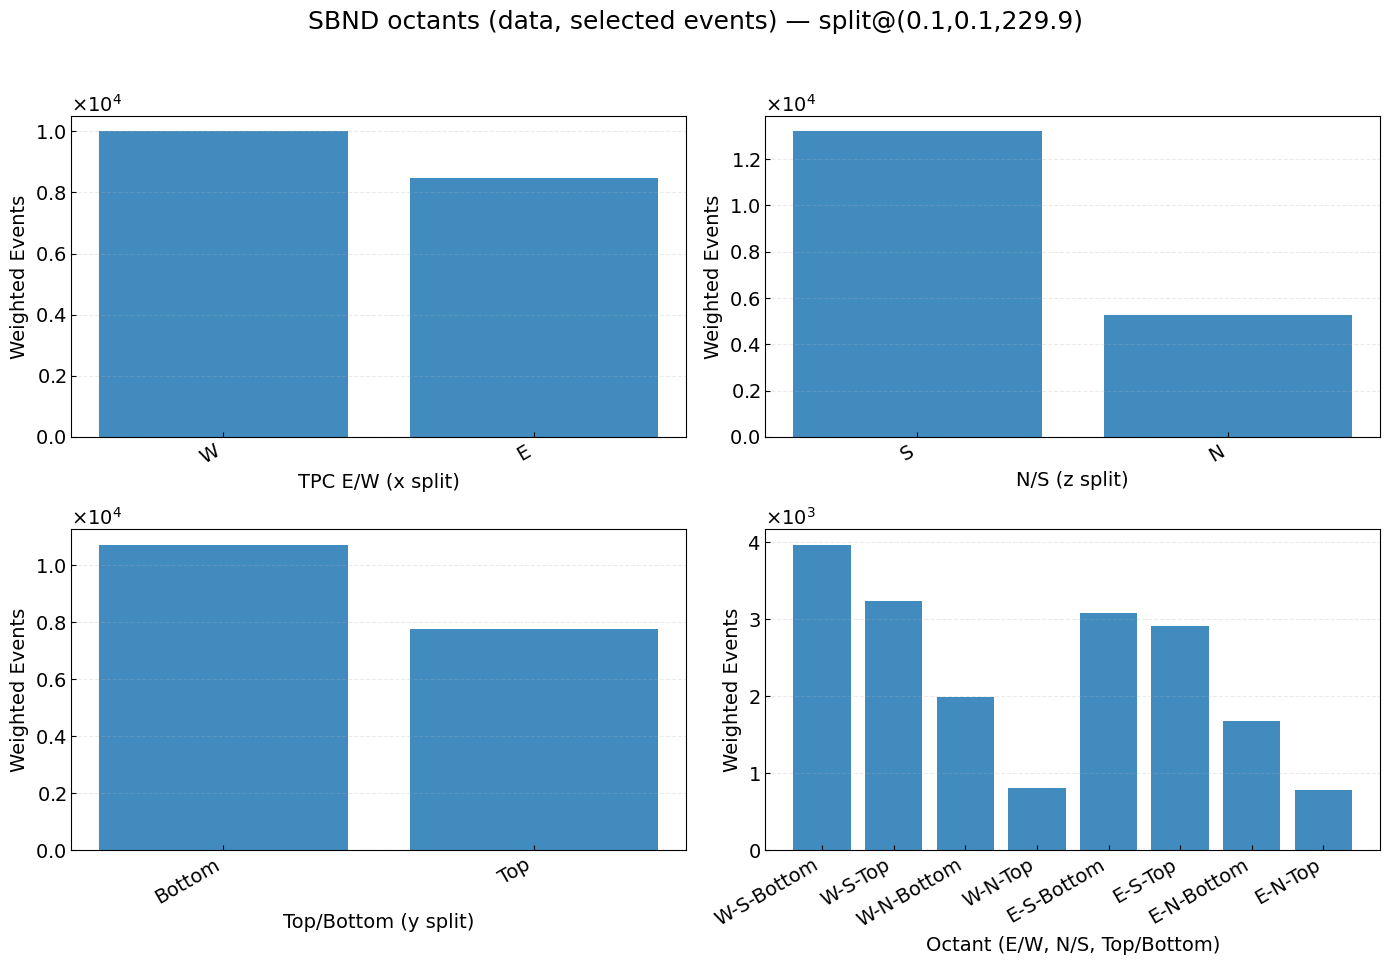

/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k": series, "w": weights}).groupby("k")["w"].sum()
/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k": series, "w": weights}).groupby("k")["w"].sum()
/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k

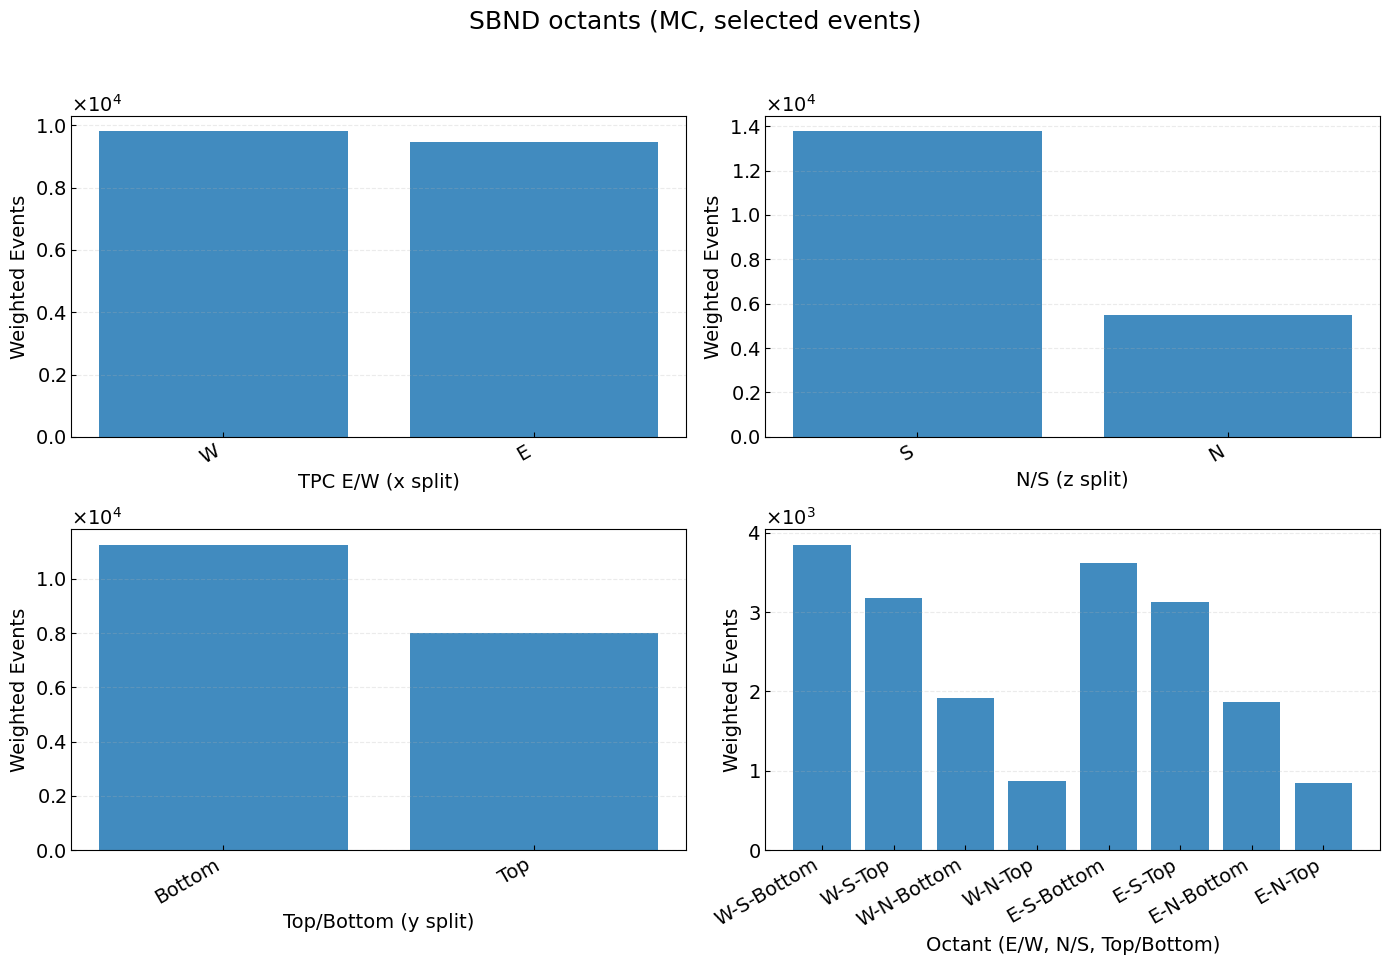

/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k": series, "w": weights}).groupby("k")["w"].sum()
/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k": series, "w": weights}).groupby("k")["w"].sum()
/tmp/ipykernel_1139182/621594516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = pd.DataFrame({"k

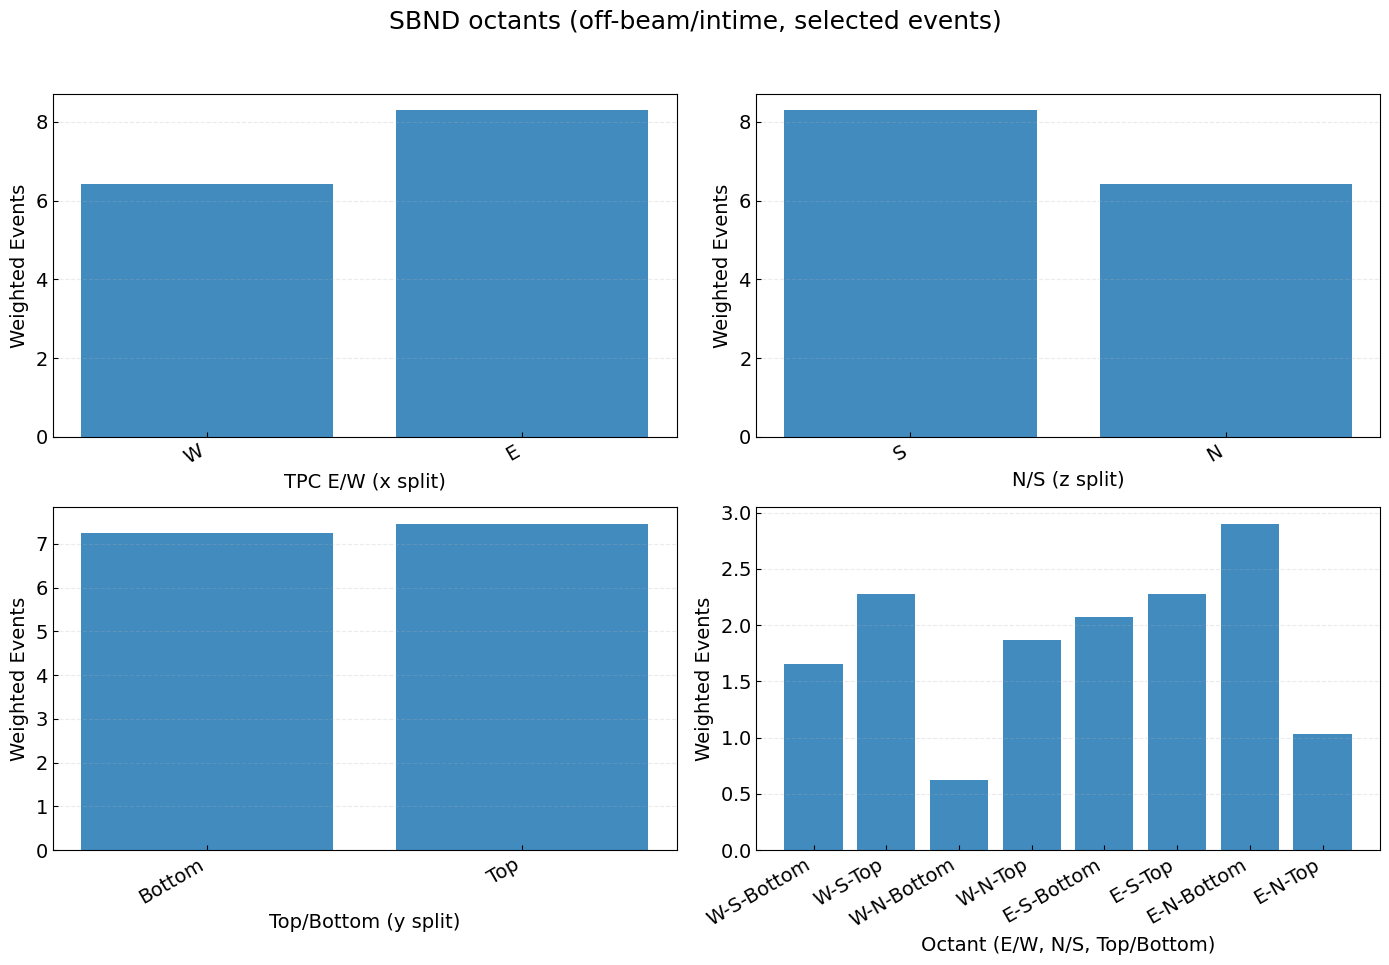

{'ew': W    6.428362
 E    8.294660
 dtype: float64,
 'ns': S    8.294660
 N    6.428362
 dtype: float64,
 'tb': Bottom    7.257828
 Top       7.465194
 dtype: float64,
 'octant': W-S-Bottom    1.658932
 W-S-Top       2.281032
 W-N-Bottom    0.622100
 W-N-Top       1.866299
 E-S-Bottom    2.073665
 E-S-Top       2.281032
 E-N-Bottom    2.903131
 E-N-Top       1.036833
 dtype: float64}

In [24]:
# ============================================================
# Inspect Distributions in Detector Quadrants and Octants
#   - SBND volume octants: TPC E/W (x), N/S (z), top/bottom (y)
#     E/W: negative x → East (x < x0); positive x → West (x >= x0)
#     N/S: lower z → North (z < z0); higher z → South (z >= z0)
# ============================================================

def _weighted_counts(series, weights):
    if isinstance(series.dtype, pd.CategoricalDtype):
        cats = series.dtype.categories
        out = pd.Series(0.0, index=cats, dtype=float)
        grp = pd.DataFrame({"k": series, "w": weights}).groupby("k")["w"].sum()
        out.loc[grp.index] = grp.values
        return out
    return pd.DataFrame({"k": series, "w": weights}).groupby("k")["w"].sum().sort_index()


def _add_sbnd_octant_labels(df, x0, y0, z0):
    x = df.slc.vertex.x.astype(float)
    y = df.slc.vertex.y.astype(float)
    z = df.slc.vertex.z.astype(float)

    ew = np.where(x < x0, "E", "W")  # SBND: negative x is East
    ns = np.where(z < z0, "N", "S")  # SBND: lower z is North
    tb = np.where(y >= y0, "Top", "Bottom")
    octant = np.char.add(np.char.add(np.char.add(ew, "-"), np.char.add(ns, "-")), tb)

    ew = pd.Categorical(ew, categories=["W", "E"], ordered=True)
    ns = pd.Categorical(ns, categories=["S", "N"], ordered=True)
    tb = pd.Categorical(tb, categories=["Bottom", "Top"], ordered=True)
    octant = pd.Categorical(
        octant,
        categories=[
            "W-S-Bottom", "W-S-Top", "W-N-Bottom", "W-N-Top",
            "E-S-Bottom", "E-S-Top", "E-N-Bottom", "E-N-Top",
        ],
        ordered=True,
    )

    out = df.copy()
    out[("sbnd", "octant", "ew", "", "", "", "")] = ew
    out[("sbnd", "octant", "ns", "", "", "", "")] = ns
    out[("sbnd", "octant", "tb", "", "", "", "")] = tb
    out[("sbnd", "octant", "octant", "", "", "", "")] = octant
    return out


def _evt_weights_octant(frame):
    c = frame.columns
    tops = set(c.get_level_values(0) if isinstance(c, pd.MultiIndex) else c)
    if "pot_weight" in tops:
        return frame["pot_weight"].astype(float)
    return pd.Series(np.ones(len(frame)), index=frame.index, dtype=float)


def _plot_octant_bars(df, title, save_base):
    w = _evt_weights_octant(df)
    ew = df["sbnd"].octant.ew
    ns = df["sbnd"].octant.ns
    tb = df["sbnd"].octant.tb
    oc = df["sbnd"].octant.octant

    counts_ew = _weighted_counts(ew, w)
    counts_ns = _weighted_counts(ns, w)
    counts_tb = _weighted_counts(tb, w)
    counts_oc = _weighted_counts(oc, w)

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    for ax, counts, xlabel in [
        (axs[0], counts_ew, "TPC E/W (x split)"),
        (axs[1], counts_ns, "N/S (z split)"),
        (axs[2], counts_tb, "Top/Bottom (y split)"),
        (axs[3], counts_oc, "Octant (E/W, N/S, Top/Bottom)"),
    ]:
        xs = np.arange(len(counts.index))
        ax.bar(xs, counts.values, color="C0", alpha=0.85)
        ax.set_xticks(xs)
        ax.set_xticklabels([str(x) for x in counts.index], rotation=30, ha="right")
        ax.set_ylabel("Weighted Events")
        ax.set_xlabel(xlabel)
        ax.grid(True, axis="y", alpha=0.25)

    fig.suptitle(title, fontsize=18)
    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    if save_fig:
        fig.savefig(save_base + fig_ext, bbox_inches="tight", dpi=dpi)
    plt.show()

    return {"ew": counts_ew, "ns": counts_ns, "tb": counts_tb, "octant": counts_oc}


# Midpoints from selected DATA (consistent splits for all samples)
_vx = data_evt_df.slc.vertex.x.astype(float).to_numpy()
_vy = data_evt_df.slc.vertex.y.astype(float).to_numpy()
_vz = data_evt_df.slc.vertex.z.astype(float).to_numpy()
_x0 = 0.5 * (np.nanmin(_vx) + np.nanmax(_vx))
_y0 = 0.5 * (np.nanmin(_vy) + np.nanmax(_vy))
_z0 = 0.5 * (np.nanmin(_vz) + np.nanmax(_vz))

print_sbnd_octant_vertex_ranges(_x0, _y0, _z0)

_octant_assignments = {}
for name, sdf in [
    ("data", data_evt_df),
    ("mc", mc_evt_df),
    ("intime", intime_evt_df),
    ("data_perTPC", data_evt_df_perTPC),
    ("mc_perTPC", mc_evt_df_perTPC),
    ("intime_perTPC", intime_evt_df_perTPC),
    ("data_contTPC1", data_evt_df_contTPC1),
    ("mc_contTPC1", mc_evt_df_contTPC1),
    ("intime_contTPC1", intime_evt_df_contTPC1),
    ("data_contTPC2", data_evt_df_contTPC2),
    ("mc_contTPC2", mc_evt_df_contTPC2),
    ("intime_contTPC2", intime_evt_df_contTPC2),
]:
    _octant_assignments[name] = _add_sbnd_octant_labels(sdf, _x0, _y0, _z0)

data_evt_df = _octant_assignments["data"]
mc_evt_df = _octant_assignments["mc"]
intime_evt_df = _octant_assignments["intime"]
data_evt_df_perTPC = _octant_assignments["data_perTPC"]
mc_evt_df_perTPC = _octant_assignments["mc_perTPC"]
intime_evt_df_perTPC = _octant_assignments["intime_perTPC"]
data_evt_df_contTPC1 = _octant_assignments["data_contTPC1"]
mc_evt_df_contTPC1 = _octant_assignments["mc_contTPC1"]
intime_evt_df_contTPC1 = _octant_assignments["intime_contTPC1"]
data_evt_df_contTPC2 = _octant_assignments["data_contTPC2"]
mc_evt_df_contTPC2 = _octant_assignments["mc_contTPC2"]
intime_evt_df_contTPC2 = _octant_assignments["intime_contTPC2"]

_plot_octant_bars(
    data_evt_df,
    title=f"SBND octants (data, selected events) — split@({_x0:.1f},{_y0:.1f},{_z0:.1f})",
    save_base=path.join(save_fig_dir, "sbnd_octants_data"),
)
_plot_octant_bars(
    mc_evt_df,
    title="SBND octants (MC, selected events)",
    save_base=path.join(save_fig_dir, "sbnd_octants_mc"),
)
_plot_octant_bars(
    intime_evt_df,
    title="SBND octants (off-beam/intime, selected events)",
    save_base=path.join(save_fig_dir, "sbnd_octants_intime"),
)


In [25]:
def fwd_muons_cut(df):
    cut = df.mu.pfp.trk.dir.z > 0
    return cut

mc_evt_df_fwd_muons = mc_evt_df[fwd_muons_cut(mc_evt_df)]
data_evt_df_fwd_muons = data_evt_df[fwd_muons_cut(data_evt_df)]
intime_evt_df_fwd_muons = intime_evt_df[fwd_muons_cut(intime_evt_df)]

def bwd_muons_cut(df):
    cut = df.mu.pfp.trk.dir.z < 0
    return cut

mc_evt_df_bwd_muons = mc_evt_df[bwd_muons_cut(mc_evt_df)]
data_evt_df_bwd_muons = data_evt_df[bwd_muons_cut(data_evt_df)]
intime_evt_df_bwd_muons = intime_evt_df[bwd_muons_cut(intime_evt_df)]

In [26]:
def crosser_muons_cut(df):
    cut = df.mu.pfp.trk.end.x * df.p.pfp.trk.start.x < 0
    return cut

mc_evt_df_crosser_muons_fwd = mc_evt_df[crosser_muons_cut(mc_evt_df) & fwd_muons_cut(mc_evt_df)]
data_evt_df_crosser_muons_fwd = data_evt_df[crosser_muons_cut(data_evt_df) & fwd_muons_cut(data_evt_df)]
intime_evt_df_crosser_muons_fwd = intime_evt_df[crosser_muons_cut(intime_evt_df) & fwd_muons_cut(intime_evt_df)]

mc_evt_df_crosser_muons_bwd = mc_evt_df[crosser_muons_cut(mc_evt_df) & bwd_muons_cut(mc_evt_df)]
data_evt_df_crosser_muons_bwd = data_evt_df[crosser_muons_cut(data_evt_df) & bwd_muons_cut(data_evt_df)]
intime_evt_df_crosser_muons_bwd = intime_evt_df[crosser_muons_cut(intime_evt_df) & bwd_muons_cut(intime_evt_df)]

In [27]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.03, 0.55]
ax_ylim_ratio = 1.9

data_vs_mc_plotter = partial(
    overlay_hists,
    mc_df=mc_evt_df,
    data_df=data_evt_df,
    intime_df=intime_evt_df,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

data_vs_mc_plotter_perTPC = partial(
    overlay_hists,
    mc_df=mc_evt_df_perTPC,
    data_df=data_evt_df_perTPC,
    intime_df=intime_evt_df_perTPC,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

data_vs_mc_plotter_contTPC1 = partial(
    overlay_hists,
    mc_df=mc_evt_df_contTPC1,
    data_df=data_evt_df_contTPC1,
    intime_df=intime_evt_df_contTPC1,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

data_vs_mc_plotter_TPC1 = partial(
    overlay_hists,
    mc_df=mc_evt_df_TPC1,
    data_df=data_evt_df_TPC1,
    intime_df=intime_evt_df_TPC1,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

data_vs_mc_plotter_contTPC2 = partial(
    overlay_hists,
    mc_df=mc_evt_df_contTPC2,
    data_df=data_evt_df_contTPC2,
    intime_df=intime_evt_df_contTPC2,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

data_vs_mc_plotter_TPC2 = partial(
    overlay_hists,
    mc_df=mc_evt_df_TPC2,
    data_df=data_evt_df_TPC2,
    intime_df=intime_evt_df_TPC2,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

In [28]:
data_vs_mc_plotter_fwd_muons = partial(
    overlay_hists,
    mc_df=mc_evt_df_fwd_muons,
    data_df=data_evt_df_fwd_muons,
    intime_df=intime_evt_df_fwd_muons,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

data_vs_mc_plotter_bwd_muons = partial(
    overlay_hists,
    mc_df=mc_evt_df_bwd_muons,
    data_df=data_evt_df_bwd_muons,
    intime_df=intime_evt_df_bwd_muons,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

data_vs_mc_plotter_crosser_muons_fwd = partial(
    overlay_hists,
    mc_df=mc_evt_df_crosser_muons_fwd,
    data_df=data_evt_df_crosser_muons_fwd,
    intime_df=intime_evt_df_crosser_muons_fwd,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

data_vs_mc_plotter_crosser_muons_bwd = partial(
    overlay_hists,
    mc_df=mc_evt_df_crosser_muons_bwd,
    data_df=data_evt_df_crosser_muons_bwd,
    intime_df=intime_evt_df_crosser_muons_bwd,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

In [ ]:
# mc_evt_df["del_Tp_y"] = mc_evt_df["del_Tp"] * np.sin(mc_evt_df["del_alpha"])
# mc_evt_df[("mc","del_Tp_y", "", "", "", "", "")] = mc_evt_df[("mc","del_Tp", "", "", "", "", "")] * np.sin(mc_evt_df[("mc","del_alpha", "", "", "", "", "")])

# data_evt_df["del_Tp_y"] = data_evt_df["del_Tp"] * np.sin(data_evt_df["del_alpha"])

# n_lo = len(mc_evt_df[mc_evt_df.del_Tp_x < 0])
# n_hi = len(mc_evt_df[mc_evt_df.del_Tp_x > 0])
# A  = (n_hi - n_lo) / (n_hi + n_lo)
# print(A)

# n_lo = len(mc_evt_df[mc_evt_df.del_Tp_y < 0])
# n_hi = len(mc_evt_df[mc_evt_df.del_Tp_y > 0])
# A  = (n_hi - n_lo) / (n_hi + n_lo)
# print(A)

# n_lo = len(data_evt_df[data_evt_df.del_Tp_x < 0])
# n_hi = len(data_evt_df[data_evt_df.del_Tp_x > 0])
# A  = (n_hi - n_lo) / (n_hi + n_lo)
# print(A)

# n_lo = len(data_evt_df[data_evt_df.del_Tp_y < 0])
# n_hi = len(data_evt_df[data_evt_df.del_Tp_y > 0])
# A  = (n_hi - n_lo) / (n_hi + n_lo)
# print(A)

# === Inspect Distributions in Detector Quadrants and Octants

# === End

In [29]:
var_configs = [
    # VariableConfig.all_events(),
    VariableConfig.muon_momentum(),
    VariableConfig.muon_direction(),
    # VariableConfig.proton_momentum(),
    # VariableConfig.proton_direction(),
    # VariableConfig.tki_del_Tp(),
    # VariableConfig.tki_del_Tp_x(),
    # VariableConfig.tki_del_Tp_y(),
    # VariableConfig.tki_del_p(),
    # VariableConfig.tki_del_alpha(),
    # VariableConfig.tki_del_phi(),
    ]


In [ ]:
for var_config in var_configs:

    cov, frac_uncert = get_syst_unc(var_config)

    for breakdown_type in ["topology"]:
        plot_labels_hist = [var_config.var_labels[1], pot_label, "Nominal"]
        ret = data_vs_mc_plotter(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        plot_labels_hist = [var_config.var_labels[1], pot_label, "per-TPC"]
        ret = data_vs_mc_plotter_perTPC(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir_perTPC, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Vertex in TPC1"]
        # ret = data_vs_mc_plotter_TPC1(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC1, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        plot_labels_hist = [var_config.var_labels[1], pot_label, "Contained inTPC1"]
        ret = data_vs_mc_plotter_contTPC1(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir_TPC1, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Vertex in TPC2"]
        # ret = data_vs_mc_plotter_TPC2(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        plot_labels_hist = [var_config.var_labels[1], pot_label, "Contained inTPC2"]
        ret = data_vs_mc_plotter_contTPC2(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # ret = data_vs_mc_plotter(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         syst_decomp=True,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir, "{}_{}-syst-decomp".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Forward Muons"]
        # ret = data_vs_mc_plotter_fwd_muons(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Backward Muons"]
        # ret = data_vs_mc_plotter_bwd_muons(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Crosser Muons (Forward)"]
        # ret = data_vs_mc_plotter_crosser_muons_fwd(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Crosser Muons (Backward)"]
        # ret = data_vs_mc_plotter_crosser_muons_bwd(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))


In [ ]:
var_configs = [
    # VariableConfig.muon_direction_x(),
    # VariableConfig.proton_direction_x(),
    # VariableConfig.muon_direction_y(),
    # VariableConfig.proton_direction_y(),
    VariableConfig.muon_direction_phi(),
    # VariableConfig.proton_direction_phi(),
    # VariableConfig.vertex_x(),
    # VariableConfig.vertex_y(),
    # VariableConfig.vertex_z(),
    VariableConfig.muon_end_x(),
    # VariableConfig.muon_end_y(),
    # VariableConfig.muon_end_z(),
    ]

for var_config in var_configs:


    for breakdown_type in ["topology"]:
    # for breakdown_type in ["topology", "genie", "genie_sb"]:
        frac_unc, cov = get_frac_unc(mc_evt_df, intime_evt_df, intime_evt_df, var_config)

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Nominal"]
        # ret = data_vs_mc_plotter(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        plot_labels_hist = [var_config.var_labels[1], pot_label, "per-TPC"]
        frac_unc, cov = get_frac_unc(mc_evt_df_perTPC, intime_evt_df_perTPC, intime_evt_df_perTPC, var_config)
        ret = data_vs_mc_plotter_perTPC(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir_perTPC, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Vertex in TPC1"]
        # frac_unc, cov = get_frac_unc(mc_evt_df_TPC1, intime_evt_df_TPC1, intime_evt_df_TPC1, var_config)
        # ret = data_vs_mc_plotter_TPC1(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC1, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        plot_labels_hist = [var_config.var_labels[1], pot_label, "Contained in TPC1"]
        frac_unc, cov = get_frac_unc(mc_evt_df_contTPC1, intime_evt_df_contTPC1, intime_evt_df_contTPC1, var_config)
        ret = data_vs_mc_plotter_contTPC1(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir_TPC1, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Vertex in TPC2"]
        # frac_unc, cov = get_frac_unc(mc_evt_df_TPC2, intime_evt_df_TPC2, intime_evt_df_TPC2, var_config)
        # ret = data_vs_mc_plotter_TPC2(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        plot_labels_hist = [var_config.var_labels[1], pot_label, "Contained in TPC2"]
        frac_unc, cov = get_frac_unc(mc_evt_df_contTPC2, intime_evt_df_contTPC2, intime_evt_df_contTPC2, var_config)
        ret = data_vs_mc_plotter_contTPC2(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Forward Muons"]
        # ret = data_vs_mc_plotter_fwd_muons(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Backward Muons"]
        # ret = data_vs_mc_plotter_bwd_muons(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=cov,
        #                         textchi2=True,
        #                         save_name=path.join(save_fig_dir_TPC2, "{}_{}".format(var_config.var_save_name, breakdown_type)))

# --- Per-octant variable distributions for phi / frac_unc vars (uses _SBND_OCTANT_LABELS from topology cell) ---
var_configs_phi = list(var_configs)

for oct_label in _SBND_OCTANT_LABELS:
    oct_slug = oct_label.replace("-", "_")
    oct_save_dir = path.join(save_fig_dir_octant, oct_slug)
    if save_fig and not path.exists(oct_save_dir):
        makedirs(oct_save_dir)

    d_o = data_evt_df.loc[_octant_rowmask(data_evt_df, oct_label)]
    m_o = mc_evt_df.loc[_octant_rowmask(mc_evt_df, oct_label)]
    i_o = intime_evt_df.loc[_octant_rowmask(intime_evt_df, oct_label)]
    if len(d_o) < 1 and len(m_o) < 1:
        continue

    plotter_oct = partial(
        overlay_hists,
        mc_df=m_o,
        data_df=d_o,
        intime_df=i_o,
        dirt_df=None,
        ax_ylim_ratio=ax_ylim_ratio,
        ratio=ratio,
        textloc=textloc,
        approval=approval,
        save_fig=save_fig,
    )

    for var_config in var_configs_phi:
        for breakdown_type in ["topology"]:
            frac_unc, cov = get_frac_unc(m_o, i_o, i_o, var_config)
            plot_labels_hist = [var_config.var_labels[1], pot_label, "Octant {}".format(oct_label)]
            ret = plotter_oct(
                breakdown_type=breakdown_type,
                var_config=var_config,
                plot_labels=plot_labels_hist,
                syst=cov,
                textchi2=True,
                save_name=path.join(oct_save_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)),
            )


In [37]:
var_configs = [
    # VariableConfig.muon_direction_x(),
    # VariableConfig.proton_direction_x(),
    # VariableConfig.muon_direction_y(),
    # VariableConfig.proton_direction_y(),
    VariableConfig.muon_direction_phi(),
    # VariableConfig.proton_direction_phi(),
    # VariableConfig.vertex_x(),
    # VariableConfig.vertex_y(),
    # VariableConfig.vertex_z(),
    VariableConfig.muon_end_x(),
    # VariableConfig.muon_end_y(),
    # VariableConfig.muon_end_z(),
    ]

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


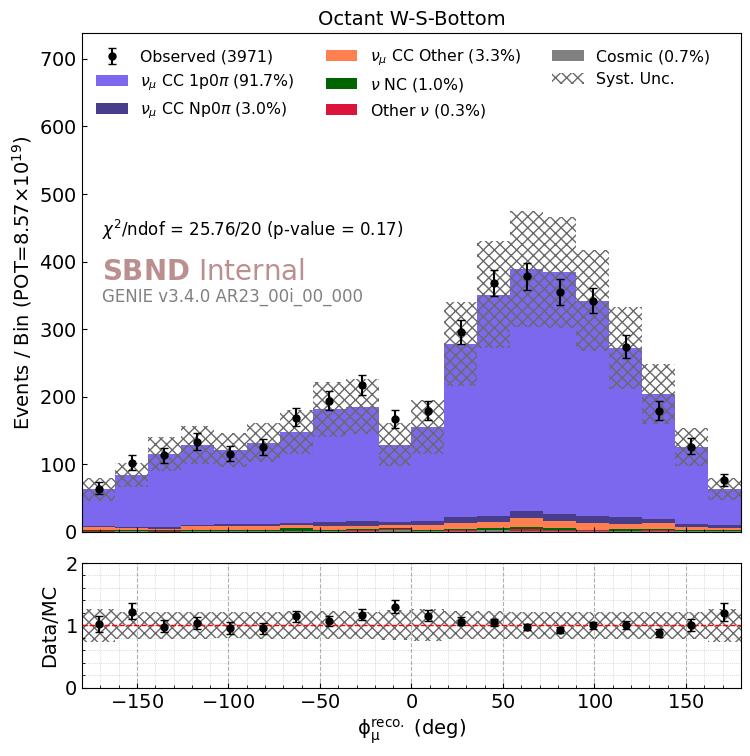

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


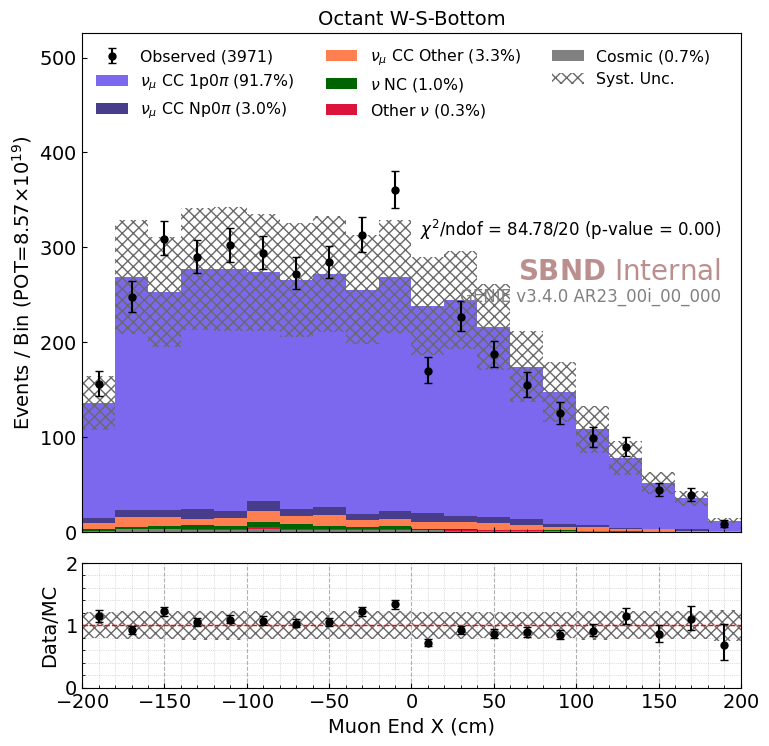

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


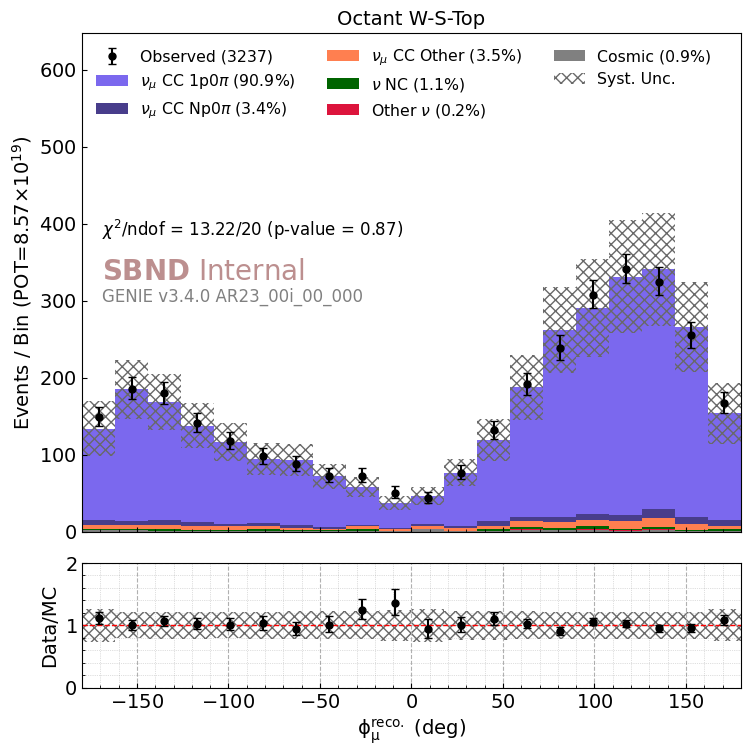

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


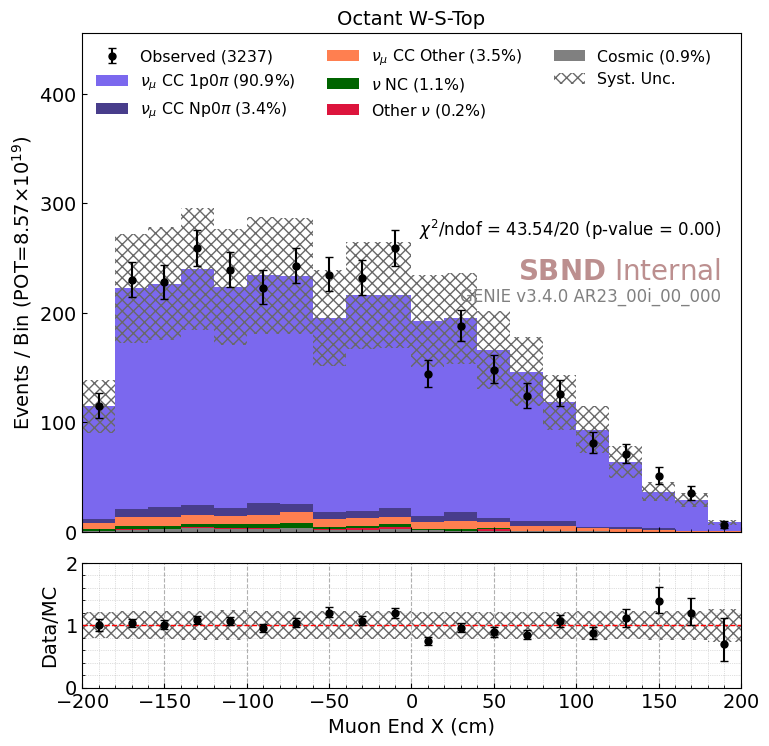

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


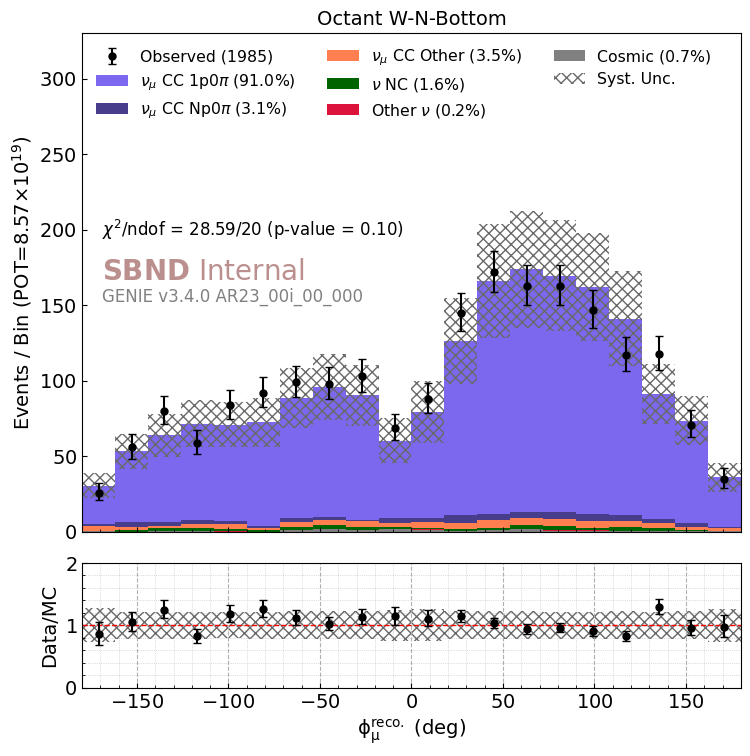

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


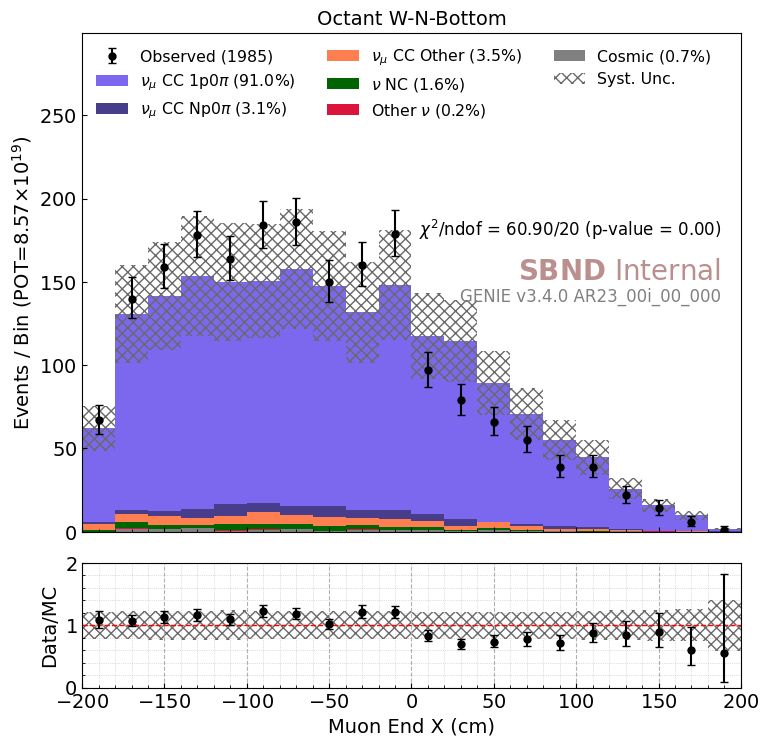

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


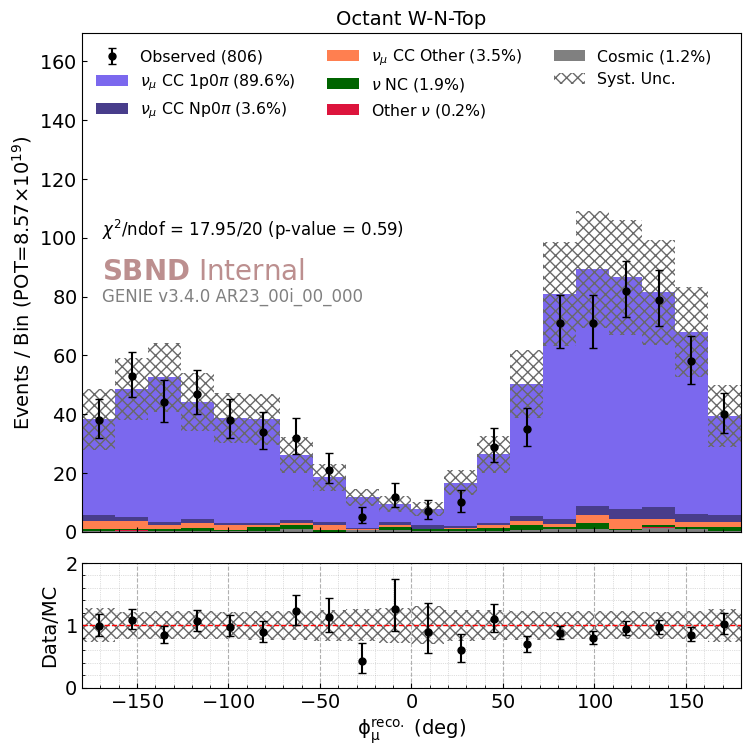

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


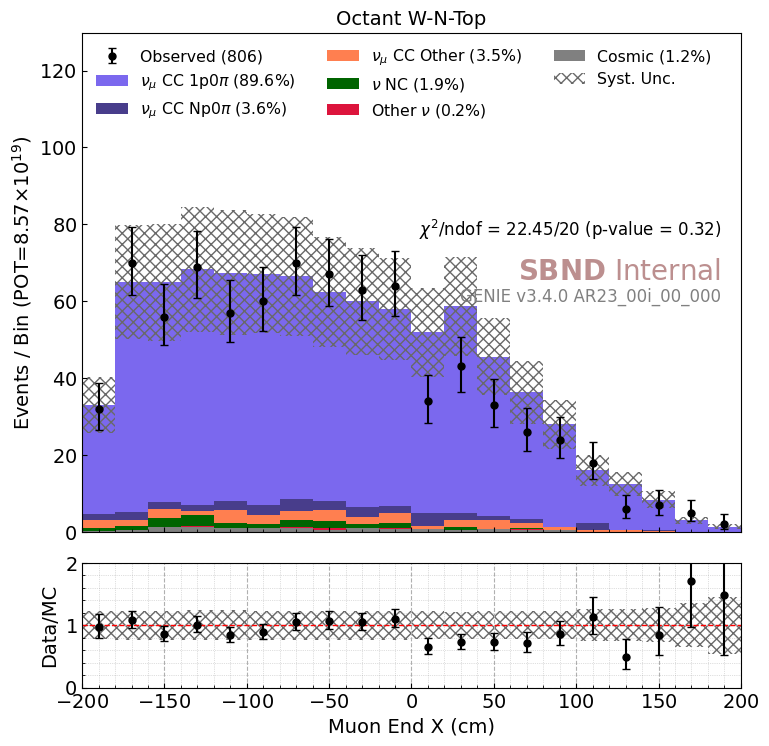

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


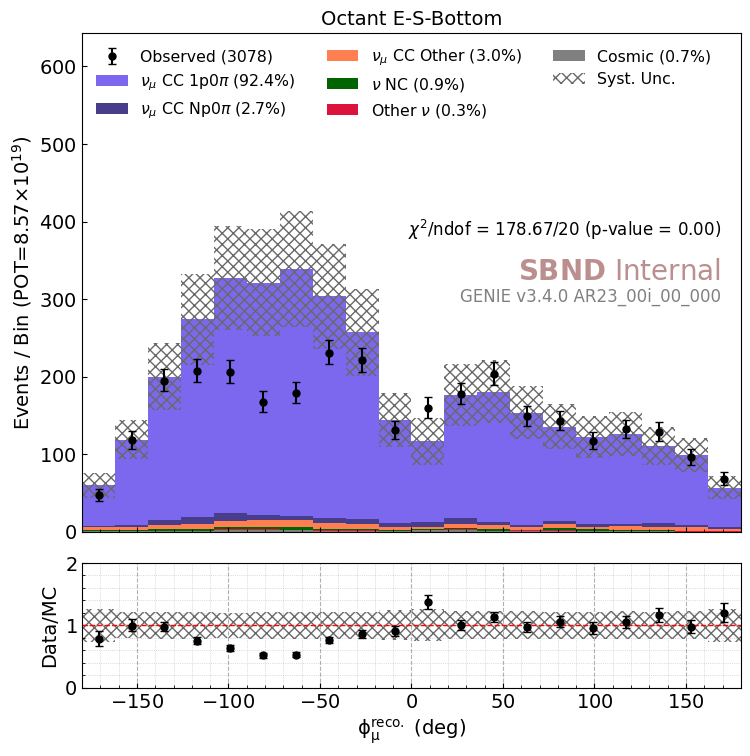

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


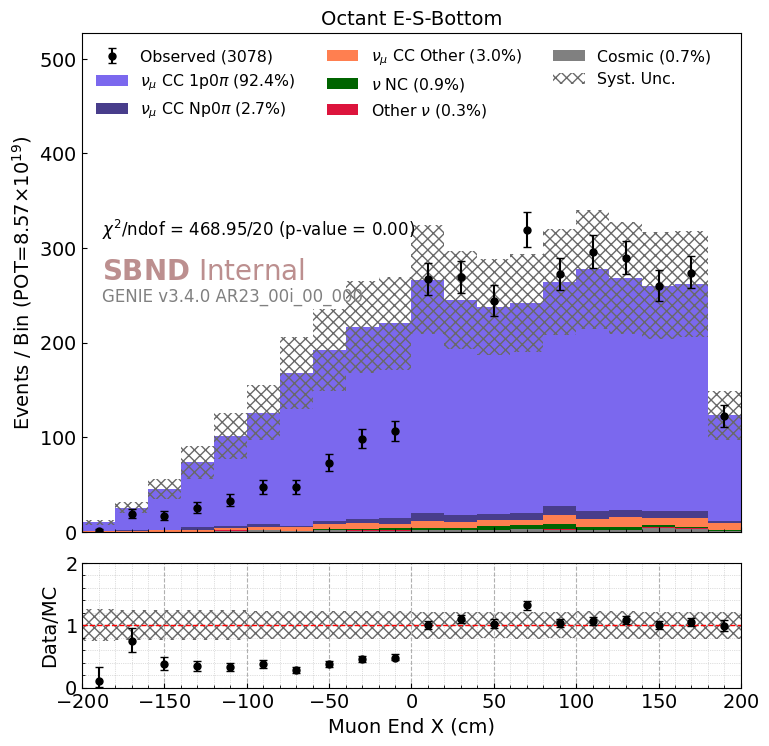

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


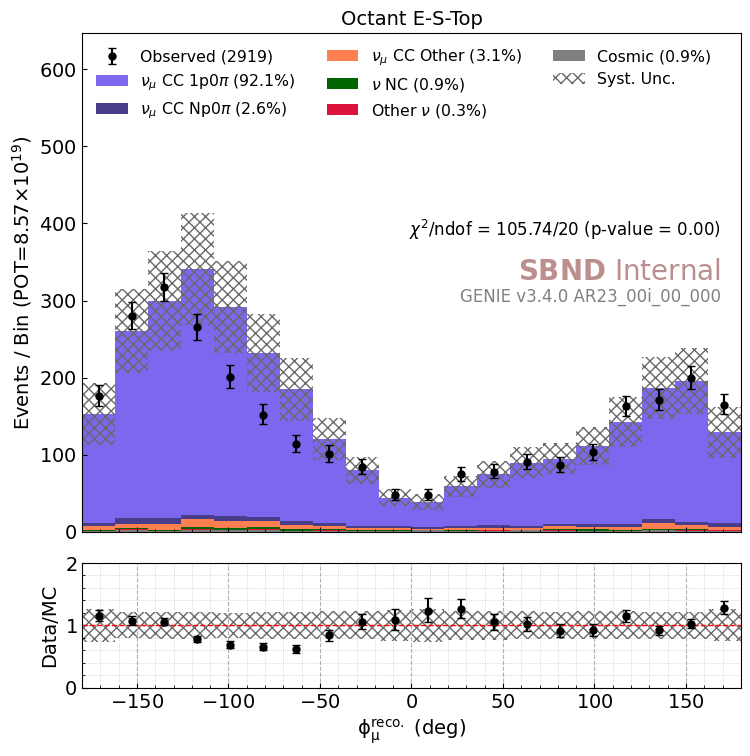

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


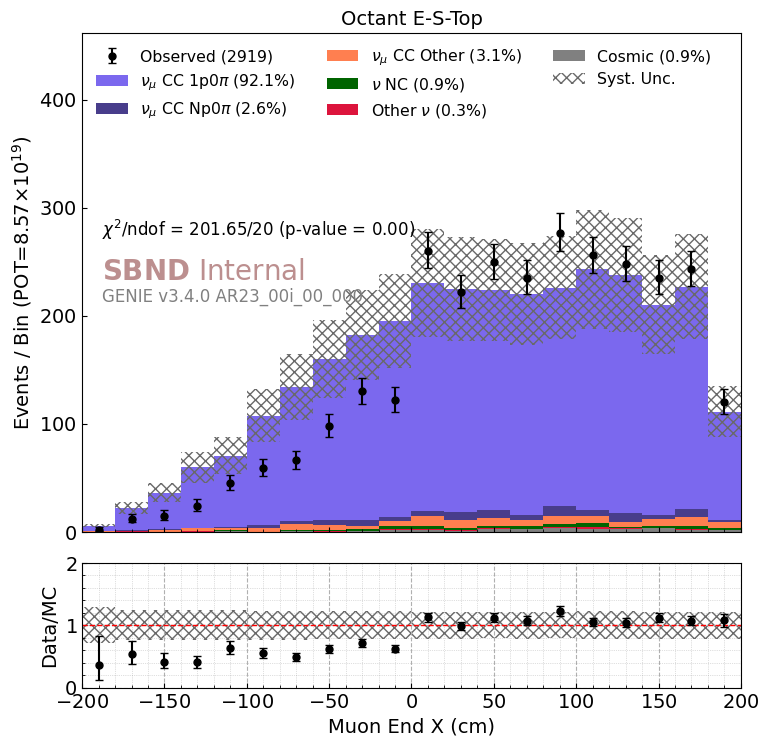

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


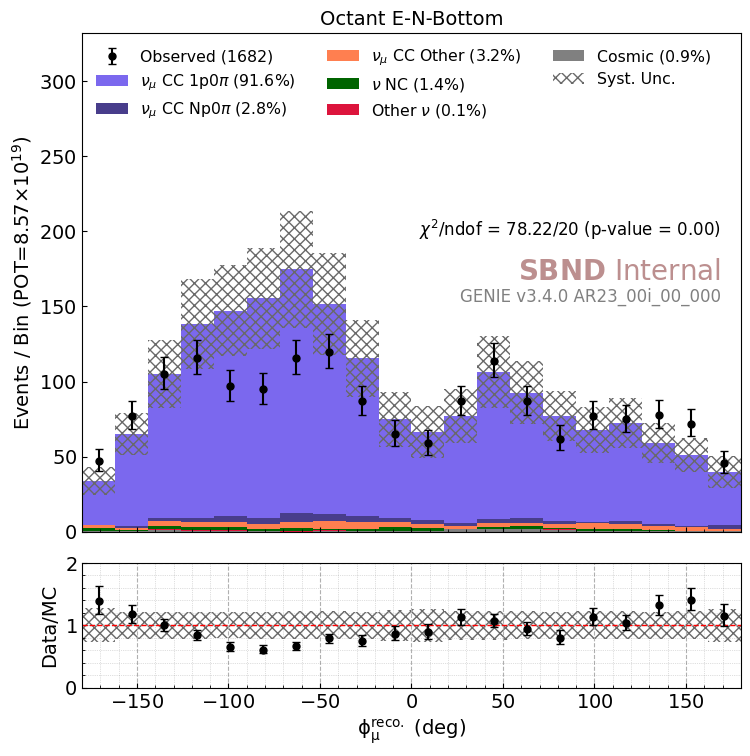

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


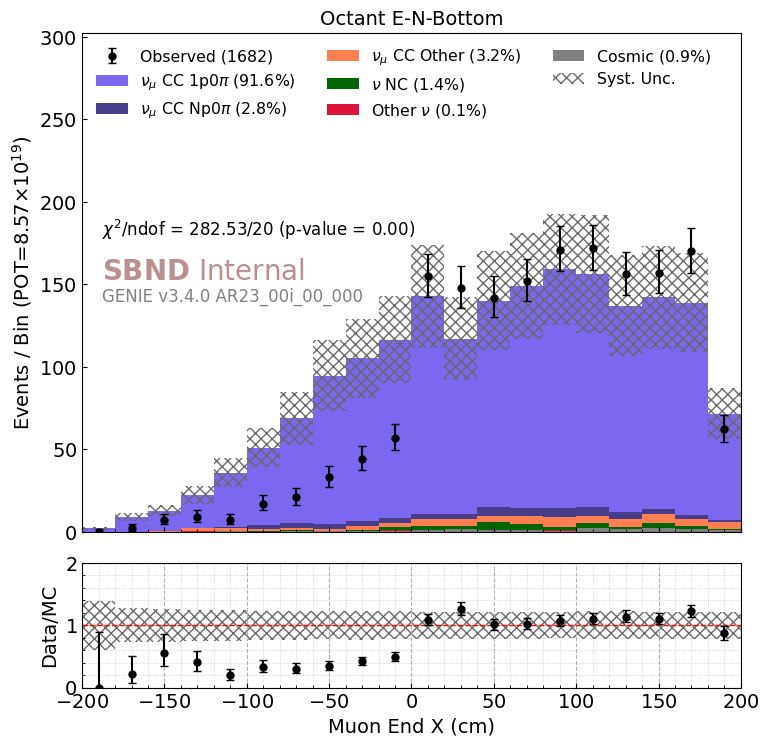

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


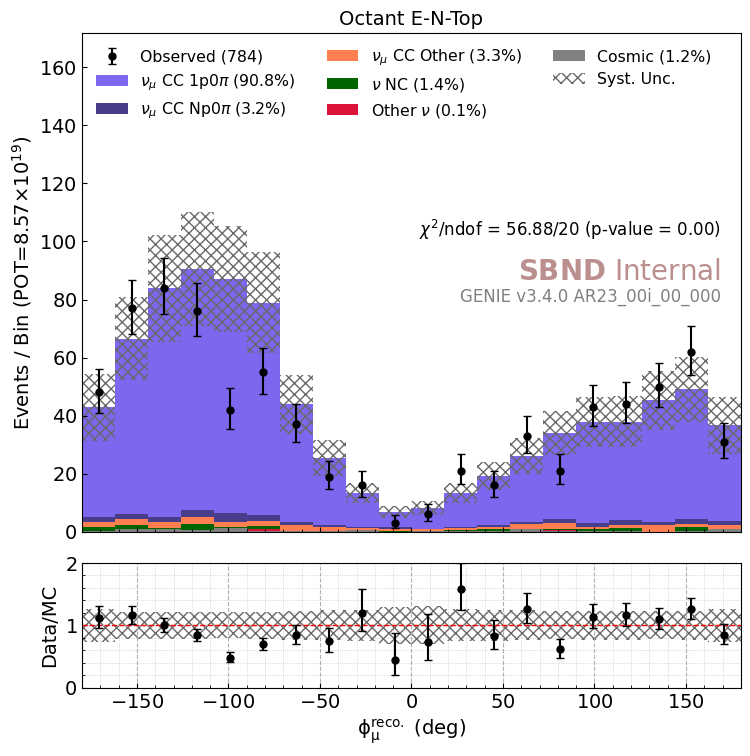

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:160: RuntimeWarning: invalid value encountered in divide
  cosmic_mc_unc = np.sqrt(np.diag(np.cov(np.array([n_intime, n_offbeam]).T) / n_intime**2))


No dirt cosmics provided


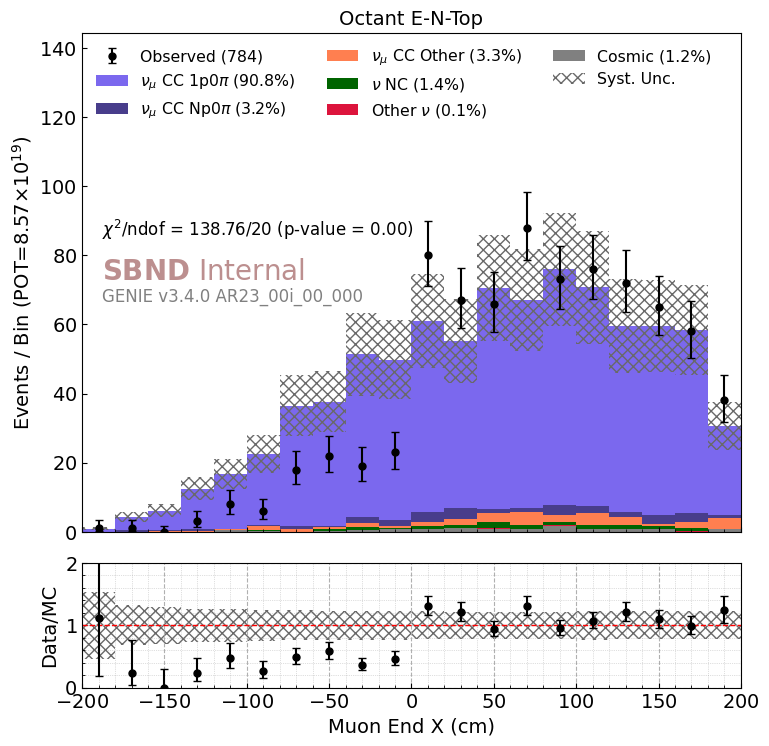

In [38]:
# --- Variable distributions per SBND octant (topology syst via get_syst_unc; requires octant-labeled dfs above) ---
_SBND_OCTANT_LABELS = (
    "W-S-Bottom", "W-S-Top", "W-N-Bottom", "W-N-Top",
    "E-S-Bottom", "E-S-Top", "E-N-Bottom", "E-N-Top",
)


def _octant_rowmask(df, oct_label):
    return df["sbnd"].octant.octant.astype(str) == oct_label


var_configs_topology = list(var_configs)

for oct_label in _SBND_OCTANT_LABELS:
    oct_slug = oct_label.replace("-", "_")
    oct_save_dir = path.join(save_fig_dir_octant, oct_slug)
    if save_fig and not path.exists(oct_save_dir):
        makedirs(oct_save_dir)

    d_o = data_evt_df.loc[_octant_rowmask(data_evt_df, oct_label)]
    m_o = mc_evt_df.loc[_octant_rowmask(mc_evt_df, oct_label)]
    i_o = intime_evt_df.loc[_octant_rowmask(intime_evt_df, oct_label)]
    if len(d_o) < 1 and len(m_o) < 1:
        continue

    plotter_oct = partial(
        overlay_hists,
        mc_df=m_o,
        data_df=d_o,
        intime_df=i_o,
        dirt_df=None,
        ax_ylim_ratio=ax_ylim_ratio,
        ratio=ratio,
        textloc=textloc,
        approval=approval,
        save_fig=save_fig,
    )

    for var_config in var_configs_topology:
        frac_unc, cov = get_frac_unc(mc_evt_df, intime_evt_df, intime_evt_df, var_config)
        for breakdown_type in ["topology"]:
            plot_labels_hist = [var_config.var_labels[1], pot_label, "Octant {}".format(oct_label)]
            ret = plotter_oct(
                breakdown_type=breakdown_type,
                var_config=var_config,
                plot_labels=plot_labels_hist,
                syst=cov,
                textchi2=True,
                save_name=path.join(oct_save_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)),
            )

In [ ]:
mc_evt_df_phicut = mc_evt_df[(mc_evt_df.mu.pfp.trk.phi > -100) & (mc_evt_df.mu.pfp.trk.phi < -50)]
data_evt_df_phicut = data_evt_df[(data_evt_df.mu.pfp.trk.phi > -100) & (data_evt_df.mu.pfp.trk.phi < -50)]
intime_evt_df_phicut = intime_evt_df[(intime_evt_df.mu.pfp.trk.phi > -100) & (intime_evt_df.mu.pfp.trk.phi < -50)]

# mc_evt_df_phicut = mc_evt_df[(mc_evt_df.mu.pfp.trk.phi > -100) & (mc_evt_df.mu.pfp.trk.phi < -50) & (mc_evt_df.slc.vertex.x < 0)]
# data_evt_df_phicut = data_evt_df[(data_evt_df.mu.pfp.trk.phi > -100) & (data_evt_df.mu.pfp.trk.phi < -50) & (data_evt_df.slc.vertex.x < 0)]
# intime_evt_df_phicut = intime_evt_df[(intime_evt_df.mu.pfp.trk.phi > -100) & (intime_evt_df.mu.pfp.trk.phi < -50) & (intime_evt_df.slc.vertex.x < 0)]

# mc_evt_df_phicut = mc_evt_df_perTPC[(mc_evt_df_perTPC.mu.pfp.trk.phi > -100) & (mc_evt_df_perTPC.mu.pfp.trk.phi < -50)]
# data_evt_df_phicut = data_evt_df_perTPC[(data_evt_df_perTPC.mu.pfp.trk.phi > -100) & (data_evt_df_perTPC.mu.pfp.trk.phi < -50)]
# intime_evt_df_phicut = intime_evt_df_perTPC[(intime_evt_df_perTPC.mu.pfp.trk.phi > -100) & (intime_evt_df_perTPC.mu.pfp.trk.phi < -50)]

# mc_evt_df_perTPC_phicut = mc_evt_df_perTPC[(mc_evt_df_perTPC.mu.pfp.trk.phi > -100) & (mc_evt_df_perTPC.mu.pfp.trk.phi < -50)] # & (mc_evt_df_perTPC.slc.vertex.x > 0)]
# data_evt_df_perTPC_phicut = data_evt_df_perTPC[(data_evt_df_perTPC.mu.pfp.trk.phi > -100) & (data_evt_df_perTPC.mu.pfp.trk.phi < -50)] # & (data_evt_df_perTPC.slc.vertex.x > 0)]
# intime_evt_df_perTPC_phicut = intime_evt_df_perTPC[(intime_evt_df_perTPC.mu.pfp.trk.phi > -100) & (intime_evt_df_perTPC.mu.pfp.trk.phi < -50)] # & (intime_evt_df_perTPC.slc.vertex.x > 0)]

data_vs_mc_plotter_phicut = partial(
    overlay_hists,
    mc_df=mc_evt_df_phicut,
    data_df=data_evt_df_phicut,
    intime_df=intime_evt_df_phicut,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

# data_vs_mc_plotter_perTPC_phicut= partial(
#     overlay_hists,
#     mc_df=mc_evt_df_perTPC_phicut,
#     data_df=data_evt_df_perTPC_phicut,
#     intime_df=intime_evt_df_perTPC_phicut,
#     dirt_df = None,
#     ax_ylim_ratio=ax_ylim_ratio,
#     ratio=ratio,
#     textloc=textloc,
#     approval=approval,
#     save_fig=save_fig, 
# )

var_configs = [
    # VariableConfig.muon_direction_x(),
    # VariableConfig.muon_direction_y(),
    VariableConfig.muon_direction_phi(),
    # VariableConfig.proton_direction_x(),
    # VariableConfig.proton_direction_y(),
    # VariableConfig.proton_direction_phi(),
    VariableConfig.vertex_x(),
    # VariableConfig.vertex_y(),
    # VariableConfig.vertex_z(),
    VariableConfig.muon_end_x(),
    # VariableConfig.muon_end_y(),
    # VariableConfig.muon_end_z(),
    ]

for var_config in var_configs:
    plot_labels_hist = [var_config.var_labels[1], pot_label, ""]
    for breakdown_type in ["topology"]:

        frac_unc, cov = get_frac_unc(mc_evt_df, intime_evt_df, intime_evt_df, var_config)
        plot_labels_hist = [var_config.var_labels[1], pot_label, r"$-100^{\circ} < \phi < -50^{\circ}$"]
        ret = data_vs_mc_plotter_phicut(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

        # frac_unc, cov = get_frac_unc(mc_evt_df, intime_evt_df, intime_evt_df, var_config)
        # plot_labels_hist = [var_config.var_labels[1], pot_label, "Nominal"]
        # ret = data_vs_mc_plotter_perTPC_phicut(breakdown_type=breakdown_type,
        #                         var_config=var_config,
        #                         plot_labels=plot_labels_hist,
        #                         syst=None,
        #                         save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

In [ ]:
colnames = ["run", "subrun", "evt"]
data_meta = data_hdr_df.loc[data_evt_df_phicut.reset_index(level=[2]).index][colnames]
data_meta.to_csv("data_meta-phicut_m100_m50.csv", index=False)

In [ ]:
var_config = VariableConfig.neutrino_energy()
plot_labels_hist = [var_config.var_labels[1], pot_label, ""]

for breakdown_type in ["topology", "genie", "genie_sb"]:
    ret = overlay_hists(breakdown_type=breakdown_type,
                        mc_df=mc_evt_df,
                        data_df=None,
                        intime_df=None,
                        dirt_df=None,
                        var_config=var_config,
                        plot_labels=plot_labels_hist,
                        ax_ylim_ratio=1.4,
                        ratio=False,
                        syst=None,
                        textloc=textloc,
                        approval=approval,
                        save_fig=save_fig, 
                        save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

# Position Breakdown

In [ ]:
phi_list = []

for phi_lo, phi_hi in zip([-1, -0.1, 0.7], [-0.7, 0.1, 1]):
    def mask_evts(df):
        phi = np.arctan2(df.p.pfp.trk.dir.x, df.p.pfp.trk.dir.y)
        return (phi > phi_lo) & (phi < phi_hi)

    data_vs_mc_plotter = partial(
        overlay_hists,
        mc_df=mc_evt_df[mask_evts(mc_evt_df)],
        data_df=data_evt_df[mask_evts(data_evt_df)],
        intime_df=intime_evt_df[mask_evts(intime_evt_df)],
        dirt_df = None,
        ax_ylim_ratio=ax_ylim_ratio,
        ratio=ratio,
        textloc=textloc,
        approval=approval,
        save_fig=save_fig, 
    )

    var_config = VariableConfig.tki_del_p()
    plot_labels_hist = [var_config.var_labels[1], pot_label, ""]

    breakdown_type = "topology"
    ret = data_vs_mc_plotter(breakdown_type=breakdown_type,
                            var_config=var_config,
                            plot_labels=plot_labels_hist,
                            syst=None,
                            save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

    phi_list.append(ret['total_mc'])

In [ ]:
def position_mask(df):
    return (df.slc.vertex.z > 20) & (df.slc.vertex.z < 100)

breakdown_type = "topology"
ret = overlay_hists(breakdown_type=breakdown_type,
                    mc_df=mc_evt_df[position_mask(mc_evt_df)],
                    data_df=data_evt_df[position_mask(data_evt_df)],
                    intime_df=intime_evt_df[position_mask(intime_evt_df)],
                    var_config=var_config,
                    plot_labels=plot_labels_hist,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    syst=syst,
                    textloc=textloc,
                    approval=approval,
                    save_fig=save_fig, 
                    save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

# Get selected event metadata for hand scanning

In [ ]:
save_meta = False

if save_meta:
    colnames = ["run", "subrun", "evt"]

    topo_categ = get_topo_category(mc_evt_df)
    print(mc_evt_df.topo_categ.value_counts())

    # ===== MC =====
    # signal
    signal_meta = mc_hdr_df.loc[topo_categ[topo_categ == 1].reset_index(level=[2]).index][colnames]
    signal_meta.to_csv("signal_meta.csv", index=False)

    # cosmic
    cosmic_meta = mc_hdr_df.loc[topo_categ[topo_categ == -1].reset_index(level=[2]).index][colnames]
    cosmic_meta.to_csv("cosmic_meta.csv", index=False)

    # nu out of FV
    nu_outfv_meta = mc_hdr_df.loc[topo_categ[topo_categ == 0].reset_index(level=[2]).index][colnames]
    nu_outfv_meta.to_csv("nu_outfv_meta.csv", index=False)

    # numu cc np0pi
    numucc_np0pi_meta = mc_hdr_df.loc[topo_categ[topo_categ == 2].reset_index(level=[2]).index][colnames]
    numucc_np0pi_meta.to_csv("numucc_np0pi_meta.csv", index=False)

    # numu cc other
    numucc_other_meta = mc_hdr_df.loc[topo_categ[topo_categ == 3].reset_index(level=[2]).index][colnames]
    numucc_other_meta.to_csv("numucc_other_meta.csv", index=False)

    # numu nc
    numucc_nc_meta = mc_hdr_df.loc[topo_categ[topo_categ == 4].reset_index(level=[2]).index][colnames]
    numucc_nc_meta.to_csv("numucc_nc_meta.csv", index=False)

    # nu other
    nu_other_meta = mc_hdr_df.loc[topo_categ[topo_categ == 5].reset_index(level=[2]).index][colnames]
    nu_other_meta.to_csv("nu_other_meta.csv", index=False)

    # ===== Data =====
    data_meta = data_hdr_df.loc[data_evt_df.reset_index(level=[2]).index][colnames]
    data_meta.to_csv("data_meta.csv", index=False)

# True Topology Breakdown of Selected Events

In [ ]:
mc_evt_df

In [ ]:
# get unique combinations of final state topologies 
# and count how many events have each combination

# this_df = mc_evt_df[IsNuInFV_NumuCC_Np0pi(mc_evt_df)].mc
# this_df = mc_evt_df[IsNuInFV_NumuCC_Other(mc_evt_df)].mc
this_df = mc_evt_df[IsNuInFV_NumuNC(mc_evt_df)].mc
# this_df = mc_evt_df.mc.copy()

particle_list = ["nmu_220MeVc", "np_300MeVc", "npi_70MeVc", "npi0"]
unique_fs = this_df[particle_list].drop_duplicates().dropna()
unique_fs_list = []
for i in unique_fs.index:
    this_fs = []
    for particle in particle_list:
        this_n_val = unique_fs.loc[i][particle].values[0]
        this_fs.append(int(this_n_val))
    unique_fs_list.append(this_fs)
print(len(unique_fs_list), "unique final state combinations")

# count how many events have each combination
n_list = []
perc_list = []
for uc in unique_fs_list:
    for pidx, particle in enumerate(particle_list):
        if pidx == 0:
            fs_mask = (this_df[particle] == uc[pidx]) 
        else:
            fs_mask = fs_mask & (this_df[particle] == uc[pidx])
    this_type_n = len(this_df[fs_mask])
    n_mc_tot = len(mc_evt_df) * mc_evt_df.pot_weight.unique()[0]
    n_intime_tot = len(intime_evt_df) * intime_evt_df.pot_weight.unique()[0]
    n_dirt_tot = len(dirt_evt_df) * dirt_evt_df.pot_weight.unique()[0]
    # this_type_perc = this_type_n * mc_evt_df.pot_weight.unique()[0] / (n_mc_tot + n_intime_tot + n_dirt_tot)
    this_type_perc = this_type_n * mc_evt_df.pot_weight.unique()[0] / (n_mc_tot + n_intime_tot + n_dirt_tot)
    n_list.append(this_type_n)
    perc_list.append(this_type_perc)
    print(uc, this_type_perc*100, this_type_n)

print(sum(perc_list))

In [ ]:
# momentum resolution 

# muon
P_bins=np.array([0.22, 0.27, 0.32, 0.37, 0.42, 0.47, 0.52, 0.57, 0.62, 0.7, 0.8, 0.9, 1.0])
plot_bins = np.linspace(-0.2, 0.2, 51)
for i in range(6):
    true_p_cut = (P_bins[i*2] + P_bins[i*2+1]) / 2
    mask = (mc_evt_df.mu.pfp.trk.truth.p.totp > true_p_cut)
    this_df = mc_evt_df[mask & (mc_evt_df.mu.pfp.trk.truth.p.pdg == 13)]
    frac_diff = (this_df.mu.pfp.trk.rangeP.p_muon - this_df.mu.pfp.trk.truth.p.totp) / this_df.mu.pfp.trk.truth.p.totp
    label = f"[{P_bins[i*2]:.2f}, {P_bins[i*2+1]:.2f}]"
    plt.hist(frac_diff, bins=plot_bins, histtype="step", label=label, density=True)

# big legend title  
plt.legend(fontsize=12, title=r"True $P$ [GeV/c]", title_fontsize=14)
plt.xlabel(r"$(P_\mu^{reco.} - P_\mu^{true})/P_\mu^{true}$")
plt.ylabel(r"Muon Candidates (Area Normalized)")

textloc=[0.05, 0.95]
approval="internal"
textloc_x, textloc_ha = get_textloc_x(frac_diff, plot_bins, textloc)
textloc_y = textloc[1]
add_approval_text(approval, textloc_x, textloc_y, textloc_ha)

plt.savefig(path.join(save_fig_dir, "muon_momentum_frac_diff.png"), dpi=300)
plt.show()

# proton
P_bins=np.array([0.3, 0.37, 0.44, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.])
plot_bins = np.linspace(-0.2, 0.2, 51)
for i in range(6):
    true_p_cut = (P_bins[i*2] + P_bins[i*2+1]) / 2
    mask = (mc_evt_df.p.pfp.trk.truth.p.totp > true_p_cut)
    this_df = mc_evt_df[mask]
    frac_diff = (this_df.p.pfp.trk.P.p_proton - this_df.p.pfp.trk.truth.p.totp) / this_df.p.pfp.trk.truth.p.totp
    label = f"[{P_bins[i*2]:.2f}, {P_bins[i*2+1]:.2f}]"
    plt.hist(frac_diff, bins=plot_bins, histtype="step", label=label, density=True)

# big legend title  
plt.legend(fontsize=12, title=r"True $P$ [GeV/c]", title_fontsize=14)
plt.xlabel(r"$(P_p^{reco.} - P_p^{true})/P_p^{true}$")
plt.ylabel(r"Proton Candidates (Area Normalized)")

textloc=[0.05, 0.95]
approval="internal"
textloc_x, textloc_ha = get_textloc_x(frac_diff, plot_bins, textloc)
textloc_y = textloc[1]
add_approval_text(approval, textloc_x, textloc_y, textloc_ha)

plt.savefig(path.join(save_fig_dir, "proton_momentum_frac_diff.png"), dpi=300)
plt.show()